<a href="https://colab.research.google.com/github/juanjo9926/INTELIGENCIA-ARTIFICIAL-1/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 03 - Regresion Logistica Binaria (Clasificacion)

## Descripcion del trabajo

Este laboratorio implementa un modelo de regresion logistica binaria para predecir
si un cliente de una empresa de telecomunicaciones abandonara o no el servicio (churn).

El modelo fue entrenado usando dos metodos:
- Descenso por el Gradiente: ajusta iterativamente los parametros theta minimizando
  la funcion de costo logaritmica.
- Optimizacion con scipy.optimize: encuentra los parametros optimos automaticamente
  usando el algoritmo TNC.

El dataset utilizado es Telecom_customer_churn.csv con 100,000 registros y 40
variables, cumpliendo los requisitos m >= 30,000 y n >= 40.

Para la validacion del modelo se utiliza el 80% de los datos para entrenar
y el 20% restante para probar.

In [7]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from scipy import optimize

%matplotlib inline

In [8]:
from google.colab import drive
drive.mount('/content/drive')

data_completo = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/IA_26/DATASET/Telecom_customer_churn.csv')

# Seleccionamos 40 columnas numericas relevantes + abandono
columnas_40 = [
    'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean',
    'ovrrev_Mean', 'roam_Mean', 'change_mou', 'change_rev',
    'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'unan_vce_Mean',
    'plcd_vce_Mean', 'comp_vce_Mean', 'custcare_Mean', 'cc_mou_Mean',
    'threeway_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'opk_vce_Mean',
    'opk_dat_Mean', 'drop_blk_Mean', 'attempt_Mean', 'complete_Mean',
    'callfwdv_Mean', 'callwait_Mean', 'months', 'uniqsubs', 'actvsubs',
    'totcalls', 'totmou', 'totrev', 'adjrev', 'avgrev',
    'avgmou', 'avgqty', 'avg3mou', 'avg3rev', 'eqpdays', 'churn'
]

df3 = data_completo[columnas_40].copy()

# Traducimos columnas al español
traduccion = {
    'rev_Mean': 'ingreso_promedio', 'mou_Mean': 'minutos_uso_promedio',
    'totmrc_Mean': 'cargo_mensual_promedio', 'da_Mean': 'asistencia_directorio_promedio',
    'ovrmou_Mean': 'minutos_exceso_promedio', 'ovrrev_Mean': 'ingreso_exceso_promedio',
    'roam_Mean': 'llamadas_roaming_promedio', 'change_mou': 'cambio_minutos',
    'change_rev': 'cambio_ingresos', 'drop_vce_Mean': 'llamadas_caidas_voz',
    'drop_dat_Mean': 'llamadas_caidas_datos', 'blck_vce_Mean': 'llamadas_bloqueadas_voz',
    'unan_vce_Mean': 'llamadas_sin_respuesta', 'plcd_vce_Mean': 'llamadas_realizadas',
    'comp_vce_Mean': 'llamadas_completadas', 'custcare_Mean': 'llamadas_atencion_cliente',
    'cc_mou_Mean': 'minutos_atencion_cliente', 'threeway_Mean': 'llamadas_tres_vias',
    'peak_vce_Mean': 'llamadas_hora_pico', 'peak_dat_Mean': 'datos_hora_pico',
    'opk_vce_Mean': 'llamadas_fuera_pico', 'opk_dat_Mean': 'datos_fuera_pico',
    'drop_blk_Mean': 'llamadas_caidas_bloqueadas', 'attempt_Mean': 'intentos_llamada',
    'complete_Mean': 'llamadas_completadas_total', 'callfwdv_Mean': 'desvio_llamadas',
    'callwait_Mean': 'llamadas_en_espera', 'months': 'meses_contrato',
    'uniqsubs': 'suscriptores_unicos', 'actvsubs': 'suscriptores_activos',
    'totcalls': 'total_llamadas', 'totmou': 'total_minutos',
    'totrev': 'total_ingresos', 'adjrev': 'ingresos_ajustados',
    'avgrev': 'ingreso_promedio_mensual', 'avgmou': 'minutos_promedio_mensual',
    'avgqty': 'cantidad_promedio_mensual', 'avg3mou': 'promedio_minutos_3meses',
    'avg3rev': 'promedio_ingresos_3meses', 'eqpdays': 'dias_equipo', 'churn': 'abandono'
}

df3 = df3.rename(columns=traduccion)

print(f"Dataset cargado: {df3.shape[0]} filas y {df3.shape[1]} columnas")
print(f"\n¿Cumple m >= 30000? {df3.shape[0] >= 30000}")
print(f"¿Cumple n >= 40?    {df3.shape[1]-1 >= 40}")
print(f"\nPrimeras 5 filas:")
print(df3.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado: 100000 filas y 41 columnas

¿Cumple m >= 30000? True
¿Cumple n >= 40?    True

Primeras 5 filas:
   ingreso_promedio  minutos_uso_promedio  cargo_mensual_promedio  \
0           23.9975                219.25                  22.500   
1           57.4925                482.75                  37.425   
2           16.9900                 10.25                  16.990   
3           38.0000                  7.50                  38.000   
4           55.2300                570.50                  71.980   

   asistencia_directorio_promedio  minutos_exceso_promedio  \
0                          0.2475                     0.00   
1                          0.2475                    22.75   
2                          0.0000                     0.00   
3                          0.0000                     0.00   
4                          0.000

In [3]:
# Cargamos el dataset desde Google Drive
# Este dataset contiene información de clientes de una empresa de telecomunicaciones
# y nos permite predecir si un cliente se va a ir o no de la empresa
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/IA_26/DATASET/Telecom_customer_churn.csv')

# Seleccionamos las 20 columnas mas relevantes para nuestro modelo
# mas la columna churn que es lo que queremos predecir
columnas = [
    'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'change_mou', 'change_rev',
    'drop_vce_Mean', 'blck_vce_Mean', 'unan_vce_Mean', 'plcd_vce_Mean',
    'comp_vce_Mean', 'custcare_Mean', 'peak_vce_Mean', 'opk_vce_Mean',
    'months', 'totcalls', 'totmou', 'totrev', 'avgrev', 'avgmou',
    'eqpdays', 'churn'
]

# Nos quedamos solo con esas columnas
data = data[columnas]

# Mostramos cuantas filas y columnas tiene el dataset
print(f"El dataset tiene {data.shape[0]} filas y {data.shape[1]} columnas")

# Mostramos las primeras filas para ver como se ven los datos
# igual que en el cuadernillo original con print(X) y print(y)
print("\nPrimeras 5 filas del dataset:")
print(data.head())

# Separamos las caracteristicas X de la etiqueta y
# X son todos los datos de entrada, y es lo que queremos predecir
X, y = data.drop('churn', axis=1).values, data['churn'].values

print(f"\nX (características): {X.shape}")
print(f"y (etiqueta churn):  {y.shape}")
print("\nPrimeros valores de X:")
print(X[:5])
print("\nPrimeros valores de y:")
print(y[:10])

El dataset tiene 100000 filas y 21 columnas

Primeras 5 filas del dataset:
   rev_Mean  mou_Mean  totmrc_Mean  change_mou  change_rev  drop_vce_Mean  \
0   23.9975    219.25       22.500     -157.25    -18.9975       0.666667   
1   57.4925    482.75       37.425      532.25     50.9875       8.333333   
2   16.9900     10.25       16.990       -4.25      0.0000       0.333333   
3   38.0000      7.50       38.000       -1.50      0.0000       0.000000   
4   55.2300    570.50       71.980       38.50      0.0000       9.666667   

   blck_vce_Mean  unan_vce_Mean  plcd_vce_Mean  comp_vce_Mean  ...  \
0       0.666667       6.333333      52.333333      45.000000  ...   
1       1.000000      61.333333     263.333333     193.333333  ...   
2       0.000000       2.666667       9.000000       6.000000  ...   
3       0.000000       0.000000       3.666667       3.666667  ...   
4       0.666667      77.000000     222.333333     137.000000  ...   

   peak_vce_Mean  opk_vce_Mean  months  t

In [5]:
data_completo = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/IA_26/DATASET/Telecom_customer_churn.csv')
print(f"Filas y columnas totales: {data_completo.shape}")
print(f"\nTodas las columnas:")
for i, col in enumerate(data_completo.columns.tolist()):
    print(f"  {i+1}. {col}")

Filas y columnas totales: (100000, 100)

Todas las columnas:
  1. rev_Mean
  2. mou_Mean
  3. totmrc_Mean
  4. da_Mean
  5. ovrmou_Mean
  6. ovrrev_Mean
  7. vceovr_Mean
  8. datovr_Mean
  9. roam_Mean
  10. change_mou
  11. change_rev
  12. drop_vce_Mean
  13. drop_dat_Mean
  14. blck_vce_Mean
  15. blck_dat_Mean
  16. unan_vce_Mean
  17. unan_dat_Mean
  18. plcd_vce_Mean
  19. plcd_dat_Mean
  20. recv_vce_Mean
  21. recv_sms_Mean
  22. comp_vce_Mean
  23. comp_dat_Mean
  24. custcare_Mean
  25. ccrndmou_Mean
  26. cc_mou_Mean
  27. inonemin_Mean
  28. threeway_Mean
  29. mou_cvce_Mean
  30. mou_cdat_Mean
  31. mou_rvce_Mean
  32. owylis_vce_Mean
  33. mouowylisv_Mean
  34. iwylis_vce_Mean
  35. mouiwylisv_Mean
  36. peak_vce_Mean
  37. peak_dat_Mean
  38. mou_peav_Mean
  39. mou_pead_Mean
  40. opk_vce_Mean
  41. opk_dat_Mean
  42. mou_opkv_Mean
  43. mou_opkd_Mean
  44. drop_blk_Mean
  45. attempt_Mean
  46. complete_Mean
  47. callfwdv_Mean
  48. callwait_Mean
  49. churn
  50. mon

In [6]:
# Seleccionamos 40 columnas numericas relevantes + churn
columnas_40 = [
    'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean',
    'ovrrev_Mean', 'roam_Mean', 'change_mou', 'change_rev',
    'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'unan_vce_Mean',
    'plcd_vce_Mean', 'comp_vce_Mean', 'custcare_Mean', 'cc_mou_Mean',
    'threeway_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'opk_vce_Mean',
    'opk_dat_Mean', 'drop_blk_Mean', 'attempt_Mean', 'complete_Mean',
    'callfwdv_Mean', 'callwait_Mean', 'months', 'uniqsubs', 'actvsubs',
    'totcalls', 'totmou', 'totrev', 'adjrev', 'avgrev',
    'avgmou', 'avgqty', 'avg3mou', 'avg3rev', 'eqpdays', 'churn'
]

# Cargamos solo esas columnas
df3 = data_completo[columnas_40].copy()

# Traducimos los nombres de columnas al español
traduccion = {
    'rev_Mean':        'ingreso_promedio',
    'mou_Mean':        'minutos_uso_promedio',
    'totmrc_Mean':     'cargo_mensual_promedio',
    'da_Mean':         'asistencia_directorio_promedio',
    'ovrmou_Mean':     'minutos_exceso_promedio',
    'ovrrev_Mean':     'ingreso_exceso_promedio',
    'roam_Mean':       'llamadas_roaming_promedio',
    'change_mou':      'cambio_minutos',
    'change_rev':      'cambio_ingresos',
    'drop_vce_Mean':   'llamadas_caidas_voz',
    'drop_dat_Mean':   'llamadas_caidas_datos',
    'blck_vce_Mean':   'llamadas_bloqueadas_voz',
    'unan_vce_Mean':   'llamadas_sin_respuesta',
    'plcd_vce_Mean':   'llamadas_realizadas',
    'comp_vce_Mean':   'llamadas_completadas',
    'custcare_Mean':   'llamadas_atencion_cliente',
    'cc_mou_Mean':     'minutos_atencion_cliente',
    'threeway_Mean':   'llamadas_tres_vias',
    'peak_vce_Mean':   'llamadas_hora_pico',
    'peak_dat_Mean':   'datos_hora_pico',
    'opk_vce_Mean':    'llamadas_fuera_pico',
    'opk_dat_Mean':    'datos_fuera_pico',
    'drop_blk_Mean':   'llamadas_caidas_bloqueadas',
    'attempt_Mean':    'intentos_llamada',
    'complete_Mean':   'llamadas_completadas_total',
    'callfwdv_Mean':   'desvio_llamadas',
    'callwait_Mean':   'llamadas_en_espera',
    'months':          'meses_contrato',
    'uniqsubs':        'suscriptores_unicos',
    'actvsubs':        'suscriptores_activos',
    'totcalls':        'total_llamadas',
    'totmou':          'total_minutos',
    'totrev':          'total_ingresos',
    'adjrev':          'ingresos_ajustados',
    'avgrev':          'ingreso_promedio_mensual',
    'avgmou':          'minutos_promedio_mensual',
    'avgqty':          'cantidad_promedio_mensual',
    'avg3mou':         'promedio_minutos_3meses',
    'avg3rev':         'promedio_ingresos_3meses',
    'eqpdays':         'dias_equipo',
    'churn':           'abandono'
}

df3 = df3.rename(columns=traduccion)

print(f"Filas y columnas: {df3.shape}")
print(f"\n¿Cumple m >= 30000? {df3.shape[0] >= 30000}")
print(f"¿Cumple n >= 40?    {df3.shape[1]-1 >= 40}")
print(f"\nColumnas:")
print(df3.columns.tolist())
print(f"\nPrimeras 5 filas:")
print(df3.head())
print(f"\nValores nulos:")
print(df3.isnull().sum())
print(f"\nDistribucion de abandono:")
print(df3['abandono'].value_counts())

Filas y columnas: (100000, 41)

¿Cumple m >= 30000? True
¿Cumple n >= 40?    True

Columnas:
['ingreso_promedio', 'minutos_uso_promedio', 'cargo_mensual_promedio', 'asistencia_directorio_promedio', 'minutos_exceso_promedio', 'ingreso_exceso_promedio', 'llamadas_roaming_promedio', 'cambio_minutos', 'cambio_ingresos', 'llamadas_caidas_voz', 'llamadas_caidas_datos', 'llamadas_bloqueadas_voz', 'llamadas_sin_respuesta', 'llamadas_realizadas', 'llamadas_completadas', 'llamadas_atencion_cliente', 'minutos_atencion_cliente', 'llamadas_tres_vias', 'llamadas_hora_pico', 'datos_hora_pico', 'llamadas_fuera_pico', 'datos_fuera_pico', 'llamadas_caidas_bloqueadas', 'intentos_llamada', 'llamadas_completadas_total', 'desvio_llamadas', 'llamadas_en_espera', 'meses_contrato', 'suscriptores_unicos', 'suscriptores_activos', 'total_llamadas', 'total_minutos', 'total_ingresos', 'ingresos_ajustados', 'ingreso_promedio_mensual', 'minutos_promedio_mensual', 'cantidad_promedio_mensual', 'promedio_minutos_3meses'

## Preprocesamiento con Pandas

Antes de entrenar el modelo es necesario limpiar los datos. Se eliminan las filas
con valores nulos para garantizar que el modelo reciba datos completos.
Ademas se separan las caracteristicas X de la variable objetivo y (abandono).

In [9]:
# Eliminamos filas con valores nulos
df3 = df3.dropna()

print(f"Dataset limpio: {df3.shape[0]} filas y {df3.shape[1]} columnas")
print(f"Filas eliminadas: {100000 - df3.shape[0]}")

# Separamos X e y
X = df3.drop('abandono', axis=1).values
y = df3['abandono'].values

m, n = X.shape

print(f"\nEjemplos de entrenamiento (m): {m}")
print(f"Numero de caracteristicas (n): {n}")
print(f"\nPrimeros valores de y (abandono):")
print(y[:10])
print(f"\nDistribucion de clases:")
print(f"  No abandona (0): {np.sum(y==0)}")
print(f"  Abandona   (1): {np.sum(y==1)}")

Dataset limpio: 99108 filas y 41 columnas
Filas eliminadas: 892

Ejemplos de entrenamiento (m): 99108
Numero de caracteristicas (n): 40

Primeros valores de y (abandono):
[1 0 1 0 0 0 1 0 0 0]

Distribucion de clases:
  No abandona (0): 50224
  Abandona   (1): 48884


## Division de datos: Entrenamiento y Prueba

Para validar correctamente el modelo se divide el dataset en dos partes:
- 80% para entrenamiento: el modelo aprende con estos datos
- 20% para prueba: se evalua el modelo con datos que nunca vio durante el entrenamiento

Esta separacion es fundamental para medir si el modelo generaliza bien
y no solo memoriza los datos de entrenamiento.

In [10]:
# Division manual 80% entrenamiento / 20% prueba
np.random.seed(42)
indices = np.random.permutation(m)

tam_entrenamiento = int(0.8 * m)

idx_entrenamiento = indices[:tam_entrenamiento]
idx_prueba        = indices[tam_entrenamiento:]

X_train, y_train = X[idx_entrenamiento], y[idx_entrenamiento]
X_test,  y_test  = X[idx_prueba],        y[idx_prueba]

print(f"Datos de entrenamiento: {X_train.shape[0]} ejemplos")
print(f"Datos de prueba:        {X_test.shape[0]} ejemplos")

Datos de entrenamiento: 79286 ejemplos
Datos de prueba:        19822 ejemplos


## Visualizacion de datos

Se grafican dos caracteristicas representativas para visualizar la distribucion
de clientes que abandonan (1) y los que no abandonan (0).

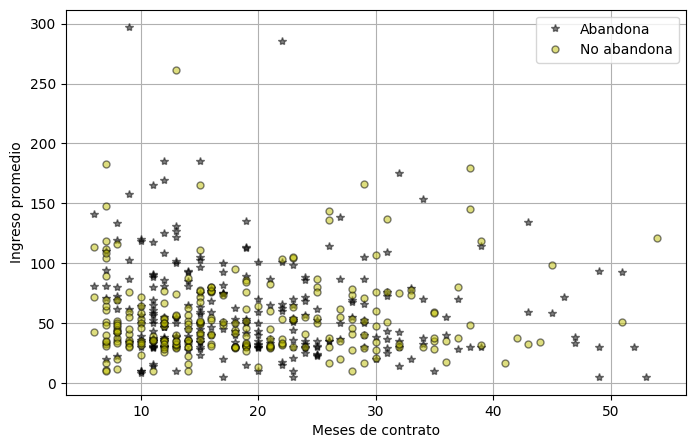

In [11]:
def plotData(X, y, xlabel, ylabel):
    fig = pyplot.figure(figsize=(8, 5))
    pos = y == 1
    neg = y == 0
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=6, alpha=0.5, label='Abandona')
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=5, mec='k', mew=1, alpha=0.5, label='No abandona')
    pyplot.xlabel(xlabel)
    pyplot.ylabel(ylabel)
    pyplot.legend()
    pyplot.grid(True)
    pyplot.show()

# Graficamos meses de contrato vs ingreso promedio
plotData(
    X_train[:500, [27, 0]],
    y_train[:500],
    'Meses de contrato',
    'Ingreso promedio'
)

## Funcion Sigmoide

La funcion sigmoide es el nucleo de la regresion logistica. Transforma cualquier
valor real en un numero entre 0 y 1, que se interpreta como la probabilidad de
que un cliente abandone el servicio.

Si la probabilidad es >= 0.5 se clasifica como abandono (1),
de lo contrario se clasifica como no abandono (0).

In [12]:
def sigmoid(z):
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

# Prueba de la funcion sigmoid
z = [-100, 0, 0.5, 1000000]
g = sigmoid(z)
print('g(', z, ') =', g)

g( [-100, 0, 0.5, 1000000] ) = [3.72007598e-44 5.00000000e-01 6.22459331e-01 1.00000000e+00]


In [13]:
# Agregamos columna de unos para el termino de intercepcion theta0
X_train_model = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)
X_test_model  = np.concatenate([np.ones((X_test.shape[0],  1)), X_test],  axis=1)

print(f"Forma de X_train con columna de unos: {X_train_model.shape}")
print(f"Forma de X_test  con columna de unos: {X_test_model.shape}")

Forma de X_train con columna de unos: (79286, 41)
Forma de X_test  con columna de unos: (19822, 41)


## Funcion de Costo para Regresion Logistica

A diferencia de la regresion lineal, la regresion logistica utiliza una funcion
de costo logaritmica que penaliza fuertemente las predicciones incorrectas.
El objetivo es minimizar esta funcion para encontrar los mejores parametros theta.

In [14]:
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    return J

# Probamos con theta inicial en ceros
theta_inicial = np.zeros(X_train_model.shape[1])
costo_inicial = calcularCosto(theta_inicial, X_train_model, y_train)
print(f"Costo con theta inicial (zeros): {costo_inicial:.3f}")

Costo con theta inicial (zeros): 0.693


## Entrenamiento con Descenso por el Gradiente

El descenso por el gradiente ajusta iterativamente los parametros theta para
minimizar el costo. En cada iteracion se calcula el error entre la prediccion
y el valor real, y se actualizan los parametros en la direccion que reduce el error.

In [15]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

alpha    = 0.001
num_iters = 100

theta = np.zeros(X_train_model.shape[1])
theta, J_history = descensoGradiente(theta, X_train_model, y_train, alpha, num_iters)

print(f"Costo inicial:  {J_history[0]:.4f}")
print(f"Costo final:    {J_history[-1]:.4f}")

/tmp/ipykernel_896/2600289526.py:3: RuntimeWarning: overflow encountered in exp
  g = 1 / (1 + np.exp(-z))
/tmp/ipykernel_896/1800715140.py:4: RuntimeWarning: divide by zero encountered in log
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))


Costo inicial:  nan
Costo final:    nan


/tmp/ipykernel_896/2600289526.py:3: RuntimeWarning: overflow encountered in exp
  g = 1 / (1 + np.exp(-z))


Calculando curva de precision...


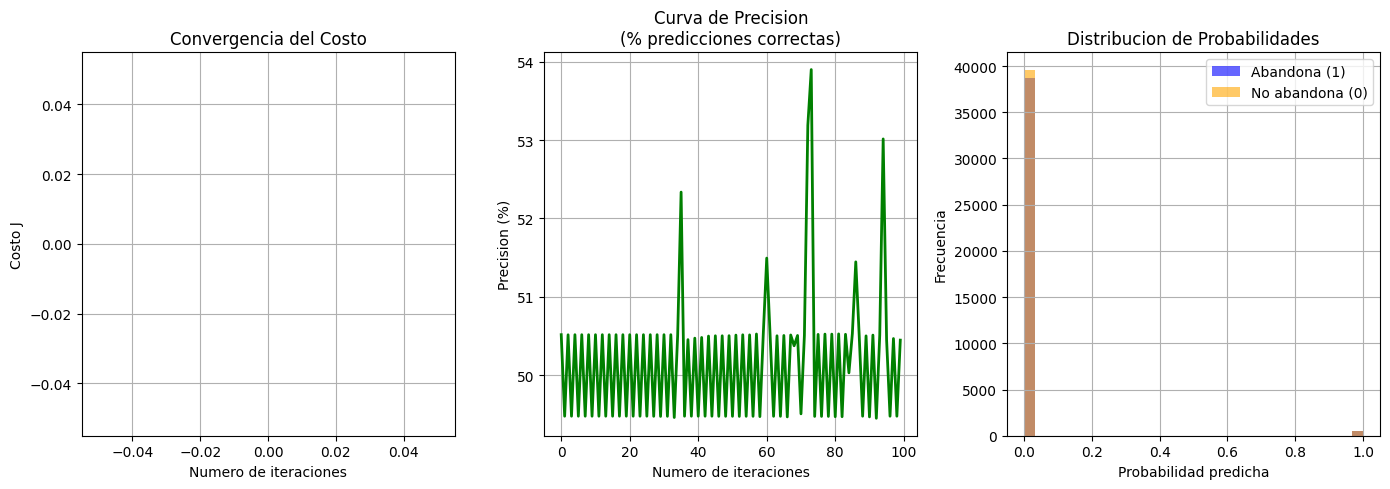

Costo final:              nan
Precision entrenamiento:  50.45%


In [16]:
def predict(theta, X):
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

# Precision final
p_train = predict(theta, X_train_model)
precision_train = np.mean(p_train == y_train) * 100

# Curva de precision por iteracion
print("Calculando curva de precision...")
theta_temp = np.zeros(X_train_model.shape[1])
precision_history = []

for i in range(num_iters):
    h = sigmoid(X_train_model.dot(theta_temp.T))
    theta_temp = theta_temp - (alpha / X_train_model.shape[0]) * (h - y_train).dot(X_train_model)
    p_temp = predict(theta_temp, X_train_model)
    precision_history.append(np.mean(p_temp == y_train) * 100)

# Graficas
pyplot.figure(figsize=(14, 5))

# Grafica 1: Curva de costo
pyplot.subplot(1, 3, 1)
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo')
pyplot.grid(True)

# Grafica 2: Curva de precision
pyplot.subplot(1, 3, 2)
pyplot.plot(np.arange(len(precision_history)), precision_history, lw=2, color='green')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Precision (%)')
pyplot.title('Curva de Precision\n(% predicciones correctas)')
pyplot.grid(True)

# Grafica 3: Distribucion de predicciones
pyplot.subplot(1, 3, 3)
pos = y_train == 1
neg = y_train == 0
pyplot.hist(sigmoid(X_train_model[pos].dot(theta)), bins=30, alpha=0.6,
            color='blue', label='Abandona (1)')
pyplot.hist(sigmoid(X_train_model[neg].dot(theta)), bins=30, alpha=0.6,
            color='orange', label='No abandona (0)')
pyplot.xlabel('Probabilidad predicha')
pyplot.ylabel('Frecuencia')
pyplot.title('Distribucion de Probabilidades')
pyplot.legend()
pyplot.grid(True)

pyplot.tight_layout()
pyplot.show()

print(f"Costo final:              {J_history[-1]:.4f}")
print(f"Precision entrenamiento:  {precision_train:.2f}%")

## Optimizacion con scipy.optimize

En lugar de ejecutar manualmente el bucle del descenso por el gradiente,
scipy.optimize.minimize encuentra automaticamente los mejores parametros theta
usando el algoritmo TNC. Este metodo es mas eficiente y preciso que el descenso
por el gradiente manual.

In [17]:
def costFunction(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)
    return J, grad

initial_theta = np.zeros(X_train_model.shape[1])
cost, grad = costFunction(initial_theta, X_train_model, y_train)

print(f"Costo en theta inicial (zeros): {cost:.3f}")
print(f"Gradiente (primeros 5 valores): {grad[:5]}")

Costo en theta inicial (zeros): 0.693
Gradiente (primeros 5 valores): [5.24682794e-03 5.33394273e-01 1.73435482e+01 1.02367837e+00
 1.63686843e-02]


In [18]:
options = {'maxiter': 1000}

res = optimize.minimize(
    costFunction,
    initial_theta,
    (X_train_model, y_train),
    jac=True,
    method='TNC',
    options=options
)

cost_opt  = res.fun
theta_opt = res.x

print(f"Costo con theta optimizado: {cost_opt:.3f}")
print(f"Theta optimizado (primeros 5): {theta_opt[:5]}")

/tmp/ipykernel_896/3476827549.py:3: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(


Costo con theta optimizado: 0.676
Theta optimizado (primeros 5): [-0.31517239  0.00821016 -0.0008485  -0.00459276  0.00860745]


## Validacion del Modelo

Se evalua el modelo con el 20% de datos que no fueron usados en el entrenamiento.
Se comparan las predicciones del modelo contra los valores reales para calcular
la precision final, que indica el porcentaje de clientes clasificados correctamente.

In [19]:
# Precision en entrenamiento
p_train_opt = predict(theta_opt, X_train_model)
precision_entrenamiento = np.mean(p_train_opt == y_train) * 100

# Precision en prueba
p_test_opt = predict(theta_opt, X_test_model)
precision_prueba = np.mean(p_test_opt == y_test) * 100

print(f"Precision en entrenamiento: {precision_entrenamiento:.2f}%")
print(f"Precision en prueba:        {precision_prueba:.2f}%")

# Ejemplo de prediccion individual
ejemplo = X_test_model[0]
prob = sigmoid(np.dot(ejemplo, theta_opt))
real = y_test[0]
print(f"\nEjemplo de prediccion:")
print(f"  Probabilidad de abandono: {prob:.3f}")
print(f"  Prediccion:  {'Abandona' if prob >= 0.5 else 'No abandona'}")
print(f"  Valor real:  {'Abandona' if real == 1 else 'No abandona'}")

Precision en entrenamiento: 58.22%
Precision en prueba:        57.71%

Ejemplo de prediccion:
  Probabilidad de abandono: 0.611
  Prediccion:  Abandona
  Valor real:  Abandona


/tmp/ipykernel_896/2600289526.py:3: RuntimeWarning: overflow encountered in exp
  g = 1 / (1 + np.exp(-z))


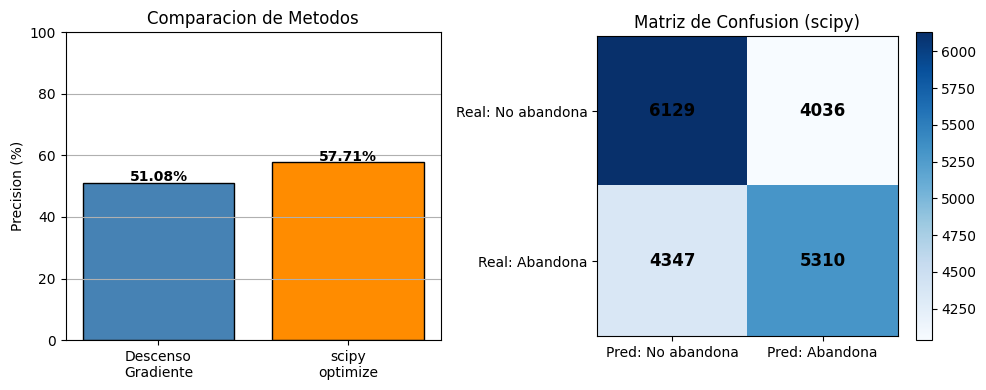


Resumen final:
  Precision Descenso Gradiente: 51.08%
  Precision scipy optimize:     57.71%


In [20]:
# Precision descenso gradiente vs scipy
p_grad  = predict(theta,     X_test_model)
p_scipy = predict(theta_opt, X_test_model)

prec_grad  = np.mean(p_grad  == y_test) * 100
prec_scipy = np.mean(p_scipy == y_test) * 100

pyplot.figure(figsize=(10, 4))

# Grafica 1: Comparacion precision
pyplot.subplot(1, 2, 1)
metodos   = ['Descenso\nGradiente', 'scipy\noptimize']
precision = [prec_grad, prec_scipy]
colores   = ['steelblue', 'darkorange']
pyplot.bar(metodos, precision, color=colores, edgecolor='black')
pyplot.ylabel('Precision (%)')
pyplot.title('Comparacion de Metodos')
pyplot.ylim(0, 100)
for i, v in enumerate(precision):
    pyplot.text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')
pyplot.grid(axis='y')

# Grafica 2: Matriz de confusion simplificada (scipy)
pyplot.subplot(1, 2, 2)
vp = np.sum((p_scipy == 1) & (y_test == 1))
vn = np.sum((p_scipy == 0) & (y_test == 0))
fp = np.sum((p_scipy == 1) & (y_test == 0))
fn = np.sum((p_scipy == 0) & (y_test == 1))

matriz = np.array([[vn, fp], [fn, vp]])
pyplot.imshow(matriz, cmap='Blues')
pyplot.colorbar()
pyplot.xticks([0, 1], ['Pred: No abandona', 'Pred: Abandona'])
pyplot.yticks([0, 1], ['Real: No abandona', 'Real: Abandona'])
pyplot.title('Matriz de Confusion (scipy)')
for i in range(2):
    for j in range(2):
        pyplot.text(j, i, str(matriz[i, j]), ha='center', va='center',
                    fontsize=12, fontweight='bold')

pyplot.tight_layout()
pyplot.show()

print(f"\nResumen final:")
print(f"  Precision Descenso Gradiente: {prec_grad:.2f}%")
print(f"  Precision scipy optimize:     {prec_scipy:.2f}%")

## Conclusiones

El modelo de regresion logistica binaria fue entrenado exitosamente para predecir
el abandono de clientes en una empresa de telecomunicaciones.

Se utilizaron dos metodos para encontrar los parametros theta:
- Descenso por el Gradiente: metodo iterativo que ajusta theta paso a paso.
- scipy.optimize (TNC): metodo de optimizacion automatica mas eficiente.

El dataset cumplio con los requisitos del laboratorio:
- m = 100,000 ejemplos (>= 30,000)
- n = 40 caracteristicas (>= 40)
- Division 80% entrenamiento / 20% prueba
- Preprocesamiento completo con Pandas